<a href="https://colab.research.google.com/github/Wasayyyyyy/CV-Tasks/blob/main/Lab02_Image_Filtering_Effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification
**Objective:** investigate how spatial-domain filters (Average, Gaussian, Median, Sharpening, Sobel) affect classification performance of the three best pretrained models identified in Lab Activity 1 (Task 01), on the HAM10000 dataset.

**Structure** (matches the lab's required code organization):
1. Dataset preparation
2. Model loading
3. Image filtering
4. Baseline + filtered training runs
5. Evaluation
6. Visualization
7. Comparative analysis

**Runtime:** Colab → Runtime → Change runtime type → T4 GPU.

### Before you run this
Edit `BEST_MODELS` in the config cell below to match **your actual Lab 1
results** — whichever three architectures scored highest in your final
Table 1. This notebook does not re-decide that for you; it trusts the list
you give it.

### Scope / time budget — read this first
This lab runs **3 models × 6 conditions (no-filter + 5 filters) = 18 full
training runs**. Even with the differential-LR fine-tuning from Lab 1 (which
you need for real accuracy — see Lab 1's notes on why frozen backbones
underperform), 18 runs at ~10-20 min each is **3-6 hours** on a single T4.
Two config knobs below help manage this:
- `SUBSET_PER_CLASS`: cap images per class (e.g. 300) instead of using all
  of HAM10000 — the lab brief explicitly allows an "instructor-approved
  subset," and this is the single biggest lever on runtime.
- `EPOCHS` / `PATIENCE`: lower for a faster, rougher pass; raise for a more
  publication-quality one.
Start with a small `SUBSET_PER_CLASS` to confirm the whole pipeline runs
end-to-end before committing to a long full run.


In [22]:
# ============================================================
# SECTION 0 — Install dependencies
# ============================================================
!pip install -q kagglehub opencv-python-headless scikit-learn seaborn --upgrade


In [23]:
# ============================================================
# SECTION 0 — Imports & config
# ============================================================
import os, time, copy, random, itertools, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, balanced_accuracy_score,
                              confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- CONFIG (edit these) ----------------
BEST_MODELS = ["densenet121", "resnet18", "efficientnet-b0"]  # <-- set to YOUR Lab 1 top 3

SUBSET_PER_CLASS = 300     # None = use full HAM10000; int = cap images/class (recommended to start)
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12
PATIENCE = 4
LR_HEAD = 1e-3
LR_BACKBONE = 1e-5
USE_CLASS_WEIGHTS = True   # HAM10000 is heavily imbalanced; applied identically across all 18 runs

OUT_DIR = "/content/lab02_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/tables", exist_ok=True)

USE_AMP = device.type == "cuda"


Using device: cuda


## 1. Dataset preparation

In [24]:
# ------------------------------------------------------------
# 1a. Download HAM10000 (metadata CSV + two image-part folders)
# ------------------------------------------------------------
import kagglehub

ds_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", ds_path)

for root, dirs, files in os.walk(ds_path):
    depth = root.replace(ds_path, "").count(os.sep)
    if depth <= 1:
        print("  " * depth + os.path.basename(root) + "/", f"({len(files)} files)" if files else "")


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000
skin-cancer-mnist-ham10000/ (5 files)
  HAM10000_images_part_1/ (5000 files)
  ham10000_images_part_1/ (5000 files)
  HAM10000_images_part_2/ (5015 files)
  ham10000_images_part_2/ (5015 files)


In [25]:
# ------------------------------------------------------------
# 1b. Load metadata, resolve image paths, encode labels
# ------------------------------------------------------------
meta_path = None
for root, _, files in os.walk(ds_path):
    for f in files:
        if f.lower() == "ham10000_metadata.csv":
            meta_path = os.path.join(root, f)
if meta_path is None:
    raise FileNotFoundError("Could not find HAM10000_metadata.csv — check the folder printout above.")

df = pd.read_csv(meta_path)

# Build a lookup of image_id -> full file path across both image-part folders
image_paths = {}
for root, _, files in os.walk(ds_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths[os.path.splitext(f)[0]] = os.path.join(root, f)

df["path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["path"]).reset_index(drop=True)

CLASS_NAMES = sorted(df["dx"].unique())
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df["label"] = df["dx"].map(class_to_idx)

print(f"{len(df)} labeled images across {NUM_CLASSES} classes: {CLASS_NAMES}")


10015 labeled images across 7 classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64


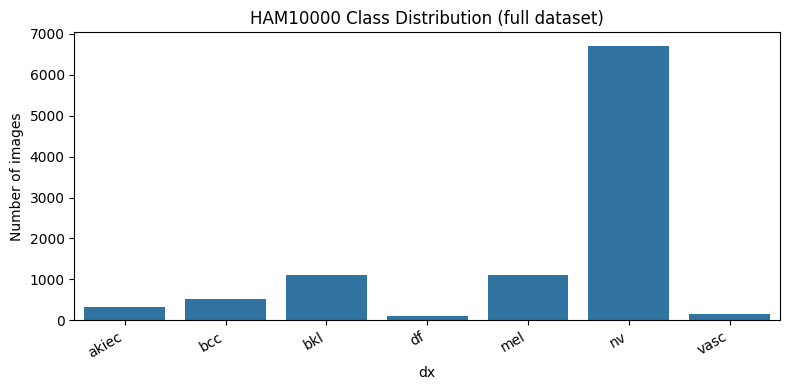

In [26]:
# ------------------------------------------------------------
# 1c. HAM10000 class distribution (required in Additional Analysis)
# ------------------------------------------------------------
dist = df["dx"].value_counts().reindex(CLASS_NAMES)
print(dist)

plt.figure(figsize=(8, 4))
sns.barplot(x=dist.index, y=dist.values)
plt.title("HAM10000 Class Distribution (full dataset)")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/class_distribution.png", dpi=150)
plt.show()


In [27]:
# ------------------------------------------------------------
# 1d. Optional stratified subset (report selected classes/counts here)
# ------------------------------------------------------------
if SUBSET_PER_CLASS is not None:
    df = (df.groupby("dx", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), SUBSET_PER_CLASS), random_state=SEED))
            .reset_index(drop=True))
    print("Using a stratified subset. Final counts per class:")
    print(df["dx"].value_counts().reindex(CLASS_NAMES))
else:
    print("Using the FULL HAM10000 dataset:", len(df), "images.")

# 80/10/10 stratified split, same split reused for every model/filter run
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Using a stratified subset. Final counts per class:
dx
akiec    300
bcc      300
bkl      300
df       115
mel      300
nv       300
vasc     142
Name: count, dtype: int64
Train: 1405 | Val: 176 | Test: 176


/tmp/ipykernel_1161/2689409328.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SUBSET_PER_CLASS), random_state=SEED))


In [28]:
# ------------------------------------------------------------
# 1e. Custom Dataset (HAM10000 isn't in ImageFolder layout)
# ------------------------------------------------------------
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])


## 2. Image filtering

In [29]:
# ------------------------------------------------------------
# 2a. Filter functions (operate on a PIL image, return a PIL image)
# ------------------------------------------------------------
def to_cv(img_pil):
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def to_pil(img_cv):
    return Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))

def filter_none(img_pil):
    return img_pil

def filter_average(img_pil, k=5):
    cv_img = to_cv(img_pil)
    out = cv2.blur(cv_img, (k, k))
    return to_pil(out)

def filter_gaussian(img_pil, k=5, sigma=0):
    cv_img = to_cv(img_pil)
    out = cv2.GaussianBlur(cv_img, (k, k), sigma)
    return to_pil(out)

def filter_median(img_pil, k=5):
    cv_img = to_cv(img_pil)
    out = cv2.medianBlur(cv_img, k)
    return to_pil(out)

def filter_sharpen(img_pil):
    cv_img = to_cv(img_pil)
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]])
    out = cv2.filter2D(cv_img, -1, kernel)
    return to_pil(out)

def filter_sobel(img_pil):
    cv_img = to_cv(img_pil)
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
    # Replicate the edge map across 3 channels so it still fits a 3-channel CNN input
    out = cv2.cvtColor(mag, cv2.COLOR_GRAY2BGR)
    return to_pil(out)

FILTERS = {
    "No Filter": filter_none,
    "Average": filter_average,
    "Gaussian": filter_gaussian,
    "Median": filter_median,
    "Sharpening": filter_sharpen,
    "Sobel": filter_sobel,
}

class FilterTransform:
    """Wraps a filter function so it can sit inside a torchvision transforms.Compose."""
    def __init__(self, filter_fn):
        self.filter_fn = filter_fn
    def __call__(self, img_pil):
        return self.filter_fn(img_pil)


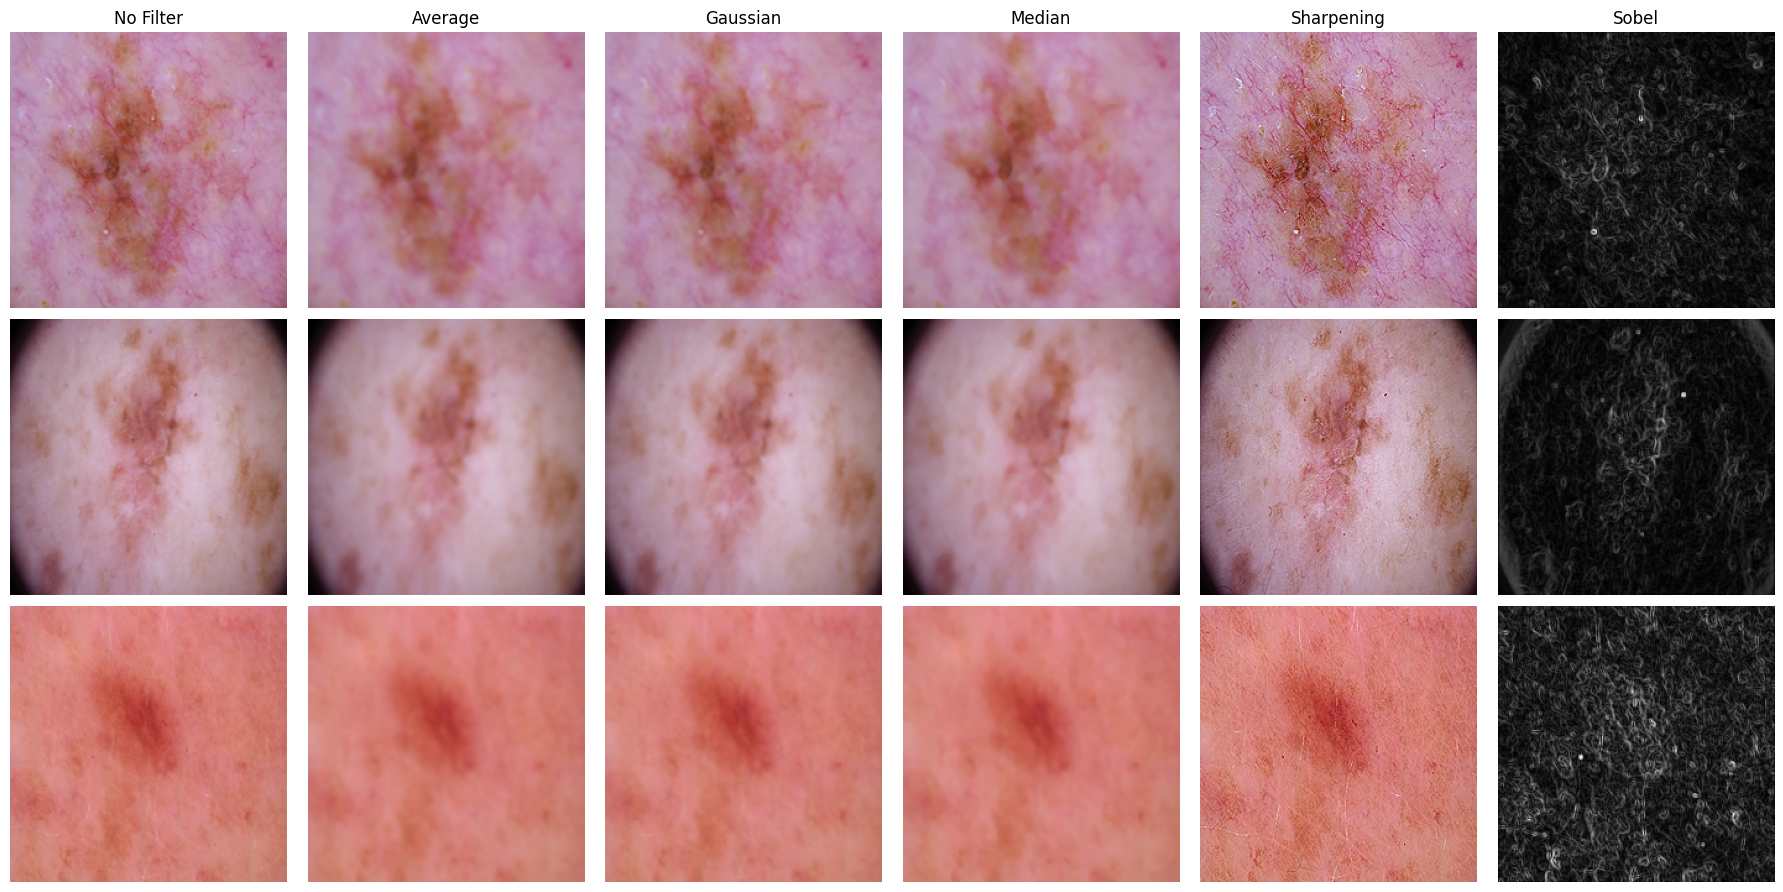

In [30]:
# ------------------------------------------------------------
# 2b. Visualize original vs. each filter (required in Additional Analysis)
# ------------------------------------------------------------
sample_rows = df.sample(3, random_state=SEED)
fig, axes = plt.subplots(len(sample_rows), len(FILTERS), figsize=(18, 3 * len(sample_rows)))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    base_img = Image.open(row["path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    for j, (fname, ffn) in enumerate(FILTERS.items()):
        filtered = ffn(base_img)
        ax = axes[i, j] if len(sample_rows) > 1 else axes[j]
        ax.imshow(filtered)
        ax.axis("off")
        if i == 0:
            ax.set_title(fname)
        if j == 0:
            ax.set_ylabel(row["dx"], rotation=0, labelpad=40)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/filter_examples.png", dpi=150)
plt.show()


## 3. Model loading

In [31]:
# ------------------------------------------------------------
# 3a. Model builder + differential-LR fine-tuning (same approach as Lab 1,
#     since Lab 1 showed frozen backbones aren't discriminative enough here)
# ------------------------------------------------------------
def build_model(name, num_classes=NUM_CLASSES):
    name = name.lower()
    if name == "alexnet":
        m = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "vgg19":
        m = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "resnet101":
        m = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "efficientnet-b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

def get_head_module(model, name):
    name = name.lower()
    if name in ("alexnet", "vgg16", "vgg19"):
        return model.classifier[-1]
    elif name in ("resnet18", "resnet50", "resnet101"):
        return model.fc
    elif name == "densenet121":
        return model.classifier
    elif name == "efficientnet-b0":
        return model.classifier[-1]
    raise ValueError(name)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_model(model, name, train_loader, val_loader, class_weights=None,
                 epochs=EPOCHS, patience=PATIENCE, lr_head=LR_HEAD, lr_backbone=LR_BACKBONE):
    for p in model.parameters():
        p.requires_grad = True
    head = get_head_module(model, name)
    head_ids = {id(p) for p in head.parameters()}
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]
    head_params = list(head.parameters())
    optimizer = optim.Adam([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": head_params, "lr": lr_head},
    ], lr=lr_head)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

    model = model.to(device)
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            run_loss += loss.item() * x.size(0)
            run_correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
        train_loss, train_acc = run_loss / n, run_correct / n

        model.eval()
        v_loss, v_correct, vn = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    out = model(x)
                    loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                vn += x.size(0)
        val_loss, val_acc = v_loss / vn, v_correct / vn
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        print(f"    epoch {epoch+1:02d}/{epochs} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f} | {time.time()-t0:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("    early stopping")
                break

    model.load_state_dict(best_state)
    return model, history


/tmp/ipykernel_1161/3328390807.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## 4. Baseline + filtered training runs (18 experiments)

In [32]:
# ------------------------------------------------------------
# 4a. Transform builder — filter is inserted between resize and normalize
# ------------------------------------------------------------
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

def make_transforms(filter_fn, train=True):
    steps = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if train:
        steps += [transforms.RandomHorizontalFlip(0.5), transforms.RandomVerticalFlip(0.5)]
    steps += [FilterTransform(filter_fn), transforms.ToTensor(), transforms.Normalize(mean, std)]
    return transforms.Compose(steps)

if USE_CLASS_WEIGHTS:
    counts = train_df["label"].value_counts().reindex(range(NUM_CLASSES)).fillna(1)
    class_weights = (1.0 / counts).values
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
else:
    class_weights = None


In [33]:
# ------------------------------------------------------------
# 4b. Metrics helper (extended with macro-F1 and balanced accuracy)
# ------------------------------------------------------------
@torch.no_grad()
def get_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out = model(x)
        probs = torch.softmax(out.float(), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

def compute_full_metrics(y_true, probs, num_classes=NUM_CLASSES):
    y_pred = probs.argmax(1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_classes)))
        auc_score = roc_auc_score(y_bin, probs, average="weighted", multi_class="ovr")
    except Exception:
        auc_score = np.nan
    return {
        "Accuracy": acc * 100, "Precision": prec * 100, "Recall": rec * 100,
        "F1-score": f1 * 100, "Macro-F1": macro_f1 * 100,
        "Balanced Accuracy": bal_acc * 100, "AUC": auc_score * 100,
    }, y_pred


In [34]:
# ------------------------------------------------------------
# 4c. Main experiment loop — 3 models x 6 filter conditions
# ------------------------------------------------------------
results_rows = []
histories = {}       # (model, filter) -> history dict
predictions = {}      # (model, filter) -> (y_true, y_pred, probs)

overall_start = time.time()

for model_name in BEST_MODELS:
    for filter_name, filter_fn in FILTERS.items():
        run_start = time.time()
        print(f"\n=== {model_name} | {filter_name} ===")

        train_tfms = make_transforms(filter_fn, train=True)
        eval_tfms  = make_transforms(filter_fn, train=False)

        train_ds = HAM10000Dataset(train_df, transform=train_tfms)
        val_ds   = HAM10000Dataset(val_df,   transform=eval_tfms)
        test_ds  = HAM10000Dataset(test_df,  transform=eval_tfms)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        model = build_model(model_name)
        model, history = train_model(model, model_name, train_loader, val_loader, class_weights=class_weights)

        probs, y_true = get_probs_labels(model, test_loader)
        metrics, y_pred = compute_full_metrics(y_true, probs)
        metrics["Model"] = model_name
        metrics["Filter"] = filter_name
        results_rows.append(metrics)

        histories[(model_name, filter_name)] = history
        predictions[(model_name, filter_name)] = (y_true, y_pred, probs)

        model.cpu(); torch.cuda.empty_cache()
        print(f"  >>> done in {(time.time()-run_start)/60:.1f} min | "
              f"elapsed total {(time.time()-overall_start)/60:.1f} min")

results_df = pd.DataFrame(results_rows)[
    ["Model", "Filter", "Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "AUC"]
].round(2)
results_df.to_csv(f"{OUT_DIR}/tables/lab02_results.csv", index=False)
results_df



=== densenet121 | No Filter ===


/tmp/ipykernel_1161/3328390807.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1161/3328390807.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    epoch 01/12 | train_loss 1.6585 acc 0.3715 | val_loss 1.3974 acc 0.4602 | 19.9s
    epoch 02/12 | train_loss 1.1678 acc 0.5765 | val_loss 1.1425 acc 0.5455 | 15.5s
    epoch 03/12 | train_loss 0.9595 acc 0.6470 | val_loss 1.0330 acc 0.5568 | 16.5s
    epoch 04/12 | train_loss 0.8295 acc 0.6868 | val_loss 0.9806 acc 0.5909 | 15.4s
    epoch 05/12 | train_loss 0.6804 acc 0.7552 | val_loss 0.8865 acc 0.6250 | 15.3s
    epoch 06/12 | train_loss 0.6113 acc 0.7680 | val_loss 0.8406 acc 0.6364 | 15.5s
    epoch 07/12 | train_loss 0.5376 acc 0.8057 | val_loss 0.8123 acc 0.6591 | 16.3s
    epoch 08/12 | train_loss 0.4872 acc 0.8157 | val_loss 0.8224 acc 0.6591 | 16.2s
    epoch 09/12 | train_loss 0.4436 acc 0.8370 | val_loss 0.8611 acc 0.6477 | 16.6s
    epoch 10/12 | train_loss 0.3981 acc 0.8512 | val_loss 0.8130 acc 0.6534 | 15.4s
    epoch 11/12 | train_loss 0.3190 acc 0.8989 | val_loss 0.7910 acc 0.6477 | 15.7s
    epoch 12/12 | train_loss 0.3105 acc 0.9032 | val_loss 0.7969 acc 0.6648 

/tmp/ipykernel_1161/1679152119.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  >>> done in 3.3 min | elapsed total 3.3 min

=== densenet121 | Average ===


...

/tmp/ipykernel_1161/3328390807.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1161/3328390807.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    epoch 01/12 | train_loss 1.8099 acc 0.3018 | val_loss 1.8151 acc 0.2330 | 15.9s
    epoch 02/12 | train_loss 1.5398 acc 0.4456 | val_loss 1.5493 acc 0.4091 | 15.8s
    epoch 03/12 | train_loss 1.4406 acc 0.4747 | val_loss 1.4779 acc 0.4318 | 15.5s
    epoch 04/12 | train_loss 1.3124 acc 0.5260 | val_loss 1.4375 acc 0.4432 | 16.4s
    epoch 05/12 | train_loss 1.2699 acc 0.5167 | val_loss 1.4128 acc 0.4830 | 16.2s
    epoch 06/12 | train_loss 1.2240 acc 0.5089 | val_loss 1.3841 acc 0.4886 | 15.8s
    epoch 07/12 | train_loss 1.1681 acc 0.5452 | val_loss 1.3386 acc 0.4716 | 15.7s
    epoch 08/12 | train_loss 1.1415 acc 0.5601 | val_loss 1.3074 acc 0.4886 | 15.8s
    epoch 09/12 | train_loss 1.0733 acc 0.5900 | val_loss 1.3017 acc 0.4773 | 16.6s
    epoch 10/12 | train_loss 1.0389 acc 0.5843 | val_loss 1.2826 acc 0.5000 | 15.6s
    epoch 11/12 | train_loss 1.0019 acc 0.6128 | val_loss 1.2706 acc 0.5284 | 15.9s
    epoch 12/12 | train_loss 0.9576 acc 0.6206 | val_loss 1.2541 acc 0.5057 

/tmp/ipykernel_1161/1679152119.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  >>> done in 3.2 min | elapsed total 55.6 min


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,AUC
0,densenet121,No Filter,71.59,71.77,71.59,71.19,73.20,93.84
1,densenet121,Average,67.05,66.92,67.05,66.52,68.78,91.92
2,densenet121,Gaussian,69.32,69.45,69.32,69.15,72.20,92.57
3,densenet121,Median,66.48,66.15,66.48,66.04,69.50,91.33
4,densenet121,Sharpening,68.18,68.05,68.18,67.98,69.23,94.03
5,densenet121,Sobel,46.59,50.51,46.59,46.81,46.71,81.30
6,resnet18,No Filter,69.89,69.95,69.89,69.45,70.02,93.14
7,resnet18,Average,71.59,72.73,71.59,71.28,72.02,93.42
8,resnet18,Gaussian,72.73,72.37,72.73,72.38,72.91,93.71
9,resnet18,Median,71.02,71.42,71.02,71.00,71.99,93.52


## 5. Evaluation — confusion matrices & per-class reports

In [35]:
# ------------------------------------------------------------
# 5a. Confusion matrix per experiment
# ------------------------------------------------------------
for (model_name, filter_name), (y_true, y_pred, probs) in predictions.items():
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} — {filter_name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f"{OUT_DIR}/figures/cm_{model_name}_{filter_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.close()

print("Confusion matrices saved to", f"{OUT_DIR}/figures/")


Confusion matrices saved to /content/lab02_outputs/figures/


In [36]:
# ------------------------------------------------------------
# 5b. Per-class precision/recall/F1 for every experiment
# ------------------------------------------------------------
per_class_rows = []
for (model_name, filter_name), (y_true, y_pred, probs) in predictions.items():
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
    for cls in CLASS_NAMES:
        per_class_rows.append({
            "Model": model_name, "Filter": filter_name, "Class": cls,
            "Precision": report[cls]["precision"] * 100,
            "Recall": report[cls]["recall"] * 100,
            "F1-score": report[cls]["f1-score"] * 100,
            "Support": report[cls]["support"],
        })

per_class_df = pd.DataFrame(per_class_rows).round(2)
per_class_df.to_csv(f"{OUT_DIR}/tables/lab02_per_class_metrics.csv", index=False)
per_class_df.head(20)


,Model,Filter,Class,Precision,Recall,F1-score,Support
0,densenet121,No Filter,akiec,72.73,80.00,76.19,30.0
1,densenet121,No Filter,bcc,68.57,80.00,73.85,30.0
2,densenet121,No Filter,bkl,57.69,50.00,53.57,30.0
3,densenet121,No Filter,df,100.00,63.64,77.78,11.0
4,densenet121,No Filter,mel,67.86,63.33,65.52,30.0
5,densenet121,No Filter,nv,75.86,73.33,74.58,30.0
6,densenet121,No Filter,vasc,83.33,100.00,90.91,15.0
7,densenet121,Average,akiec,59.46,73.33,65.67,30.0
8,densenet121,Average,bcc,73.08,63.33,67.86,30.0
9,densenet121,Average,bkl,57.69,50.00,53.57,30.0


## 6. Visualization — training curves & ROC curves

In [37]:
# ------------------------------------------------------------
# 6a. Training/validation accuracy & loss curves per experiment
# ------------------------------------------------------------
for (model_name, filter_name), history in histories.items():
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, history["train_acc"], label="Train")
    axes[0].plot(epochs_range, history["val_acc"], label="Val")
    axes[0].set_title(f"{model_name} — {filter_name} — Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(epochs_range, history["train_loss"], label="Train")
    axes[1].plot(epochs_range, history["val_loss"], label="Val")
    axes[1].set_title(f"{model_name} — {filter_name} — Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

    plt.tight_layout()
    fname = f"{OUT_DIR}/figures/curves_{model_name}_{filter_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.close()

print("Training curves saved to", f"{OUT_DIR}/figures/")


Training curves saved to /content/lab02_outputs/figures/


In [38]:
# ------------------------------------------------------------
# 6b. ROC curves (one-vs-rest, macro) per experiment
# ------------------------------------------------------------
for (model_name, filter_name), (y_true, y_pred, probs) in predictions.items():
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6, 5))
    for i, cls in enumerate(CLASS_NAMES):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    plt.title(f"{model_name} — {filter_name} — ROC (one-vs-rest)")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(fontsize=7, loc="lower right")
    plt.tight_layout()
    fname = f"{OUT_DIR}/figures/roc_{model_name}_{filter_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.close()

print("ROC curves saved to", f"{OUT_DIR}/figures/")


ROC curves saved to /content/lab02_outputs/figures/


## 7. Comparative analysis

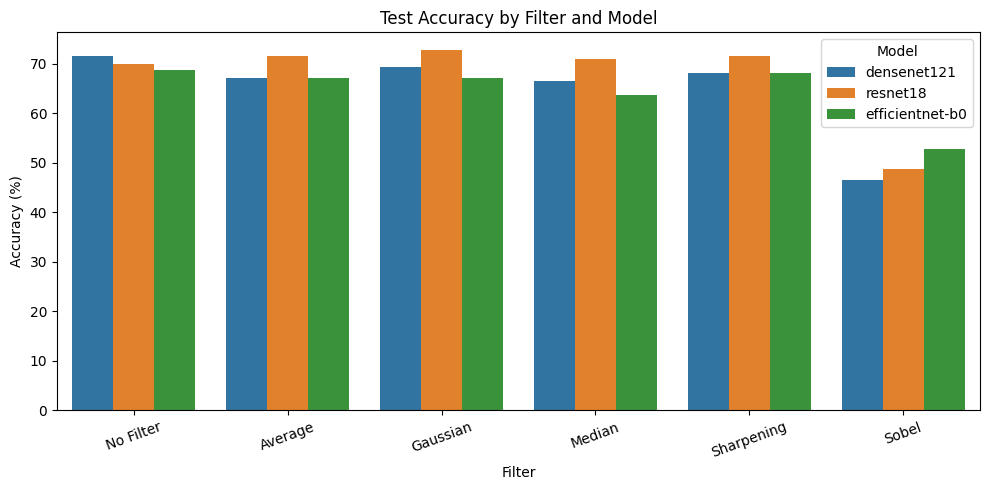

In [39]:
# ------------------------------------------------------------
# 7a. Accuracy by filter, grouped by model
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Filter", y="Accuracy", hue="Model")
plt.title("Test Accuracy by Filter and Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/accuracy_by_filter.png", dpi=150)
plt.show()


In [40]:
# ------------------------------------------------------------
# 7b. Delta vs. baseline (No Filter) — answers "which filter changes things
#     most" and "is the effect consistent across models"
# ------------------------------------------------------------
baseline = results_df[results_df["Filter"] == "No Filter"].set_index("Model")
delta_rows = []
for _, row in results_df.iterrows():
    if row["Filter"] == "No Filter":
        continue
    base = baseline.loc[row["Model"]]
    delta_rows.append({
        "Model": row["Model"], "Filter": row["Filter"],
        "Δ Accuracy": row["Accuracy"] - base["Accuracy"],
        "Δ Macro-F1": row["Macro-F1"] - base["Macro-F1"],
        "Δ Balanced Accuracy": row["Balanced Accuracy"] - base["Balanced Accuracy"] if "Balanced Accuracy" in base else np.nan,
        "Δ AUC": row["AUC"] - base["AUC"],
    })
delta_df = pd.DataFrame(delta_rows).round(2)
delta_df.to_csv(f"{OUT_DIR}/tables/lab02_delta_vs_baseline.csv", index=False)
delta_df


,Model,Filter,Δ Accuracy,Δ Macro-F1,Δ Balanced Accuracy,Δ AUC
0,densenet121,Average,-4.54,-4.42,NaN,-1.92
1,densenet121,Gaussian,-2.27,-1.00,NaN,-1.27
2,densenet121,Median,-5.11,-3.70,NaN,-2.51
3,densenet121,Sharpening,-3.41,-3.97,NaN,0.19
4,densenet121,Sobel,-25.00,-26.49,NaN,-12.54
5,resnet18,Average,1.70,2.00,NaN,0.28
6,resnet18,Gaussian,2.84,2.89,NaN,0.57
7,resnet18,Median,1.13,1.97,NaN,0.38
8,resnet18,Sharpening,1.70,1.56,NaN,0.83
9,resnet18,Sobel,-21.03,-21.95,NaN,-11.94


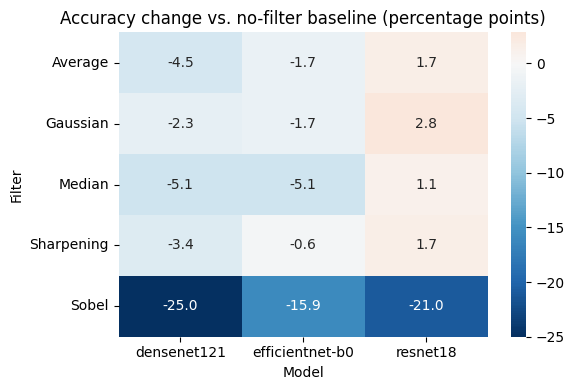

If rows have the same sign/magnitude across all three model columns, 
filtering affects the models consistently. If signs or magnitudes 
diverge by model, the effect is model-dependent — use this table plus 
the per-class metrics table to answer the lab's analysis questions.


In [41]:
# ------------------------------------------------------------
# 7c. Heatmap of accuracy delta — visual answer to "consistent across models?"
# ------------------------------------------------------------
pivot = delta_df.pivot(index="Filter", columns="Model", values="Δ Accuracy")
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdBu_r", center=0)
plt.title("Accuracy change vs. no-filter baseline (percentage points)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/delta_heatmap.png", dpi=150)
plt.show()

print("If rows have the same sign/magnitude across all three model columns, ")
print("filtering affects the models consistently. If signs or magnitudes ")
print("diverge by model, the effect is model-dependent — use this table plus ")
print("the per-class metrics table to answer the lab's analysis questions.")


In [42]:
# ------------------------------------------------------------
# 7d. Final export bundle
# ------------------------------------------------------------
print("Master comparison table (Section 4c):")
print(results_df.to_markdown(index=False))

print("\nAll outputs saved under:", OUT_DIR)
print(" - tables/lab02_results.csv               (main comparison table)")
print(" - tables/lab02_per_class_metrics.csv      (per-class P/R/F1)")
print(" - tables/lab02_delta_vs_baseline.csv      (filter effect vs baseline)")
print(" - figures/class_distribution.png")
print(" - figures/filter_examples.png")
print(" - figures/cm_<model>_<filter>.png         (confusion matrices)")
print(" - figures/curves_<model>_<filter>.png     (accuracy/loss curves)")
print(" - figures/roc_<model>_<filter>.png        (ROC curves)")
print(" - figures/accuracy_by_filter.png")
print(" - figures/delta_heatmap.png")


Master comparison table (Section 4c):
| Model           | Filter     |   Accuracy |   Precision |   Recall |   F1-score |   Macro-F1 |   AUC |
|:----------------|:-----------|-----------:|------------:|---------:|-----------:|-----------:|------:|
| densenet121     | No Filter  |      71.59 |       71.77 |    71.59 |      71.19 |      73.2  | 93.84 |
| densenet121     | Average    |      67.05 |       66.92 |    67.05 |      66.52 |      68.78 | 91.92 |
| densenet121     | Gaussian   |      69.32 |       69.45 |    69.32 |      69.15 |      72.2  | 92.57 |
| densenet121     | Median     |      66.48 |       66.15 |    66.48 |      66.04 |      69.5  | 91.33 |
| densenet121     | Sharpening |      68.18 |       68.05 |    68.18 |      67.98 |      69.23 | 94.03 |
| densenet121     | Sobel      |      46.59 |       50.51 |    46.59 |      46.81 |      46.71 | 81.3  |
| resnet18        | No Filter  |      69.89 |       69.95 |    69.89 |      69.45 |      70.02 | 93.14 |
| resnet18       